# Prototype: Combine results of calibrations from multiple years of a single location

In [2]:
import io
from collections import defaultdict
from pathlib import Path


import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly
import plotly.express as px
import plotly.graph_objects as go
import scipy.stats

## Load single location all seasons

In [5]:
location_id = "RN"
# use_years = list(range(2018, 2023))  # -()- Probe
use_years = list(range(2010, 2024))  # -()- Full

main_output_dir = Path("../../.local/mind-runner_local/validation_round_calibration")
subdir_fmt = "{location_id}_{year}"

# -------------
# Load all data
# =============
keys_list = list()
data_lists = defaultdict(lambda: list())

for year in use_years:
    out_dir = main_output_dir / subdir_fmt.format(location_id=location_id, year=year)

    if not out_dir.exists():
        print(f"WARNING: Output directory for {year} does not exist: {out_dir}")
        continue

    print(f"Loading from {out_dir}...")
    keys_list.append(year)

    # --- Posterior parameter samples
    df = pd.read_csv(
        out_dir / "stage3_posterior_samples.csv.gz",
        index_col="i_simulation",
    )
    data_lists["param_samples"].append(df)

    # --- Maximum likelihood parameters from stage 1
    series = (
        pd.read_csv(
            out_dir / "stage1_max_ll_params.csv",
            index_col="parameter_name"
        # ).T
        )["value"]
        # .reset_index(drop=True)
    )
    data_lists["maximum_likelihood"].append(series)

    # --- Calculated outbreak features
    df = pd.read_csv(
        out_dir / "outbreak_feature_stats.csv.gz",
        index_col=0, header=[0, 1], skiprows=[2]
    )
    df.index.name = "i_simulation"
    data_lists["outbreak_features"].append(df)


# Concatenate datasets
# ----------
if len(keys_list) == 0:
    raise ValueError("No data loaded. Check the output directories.")

# --- Posterior samples
param_samples_df = pd.concat(
    data_lists["param_samples"],  # List of dataframes
    axis=0,
    keys=keys_list,  # Use years as keys for the multi-index
    names=["year"],
)

# --- Max likelihood param (list of series into dataframe)
max_likelihood_df = pd.concat(
    data_lists["maximum_likelihood"],  # List of series
    axis=1,
).T
max_likelihood_df.index = use_years
max_likelihood_df.index.name = "year"

# --- Outbreak features
outbreak_features_df = pd.concat(
    data_lists["outbreak_features"],
    axis=0,
    keys=keys_list,
    names=["year"],
)

max_likelihood_df
param_samples_df
outbreak_features_df


Loading from ../../.local/mind-runner_local/validation_round_calibration/RN_2010...
Loading from ../../.local/mind-runner_local/validation_round_calibration/RN_2011...
Loading from ../../.local/mind-runner_local/validation_round_calibration/RN_2012...
Loading from ../../.local/mind-runner_local/validation_round_calibration/RN_2013...
Loading from ../../.local/mind-runner_local/validation_round_calibration/RN_2014...
Loading from ../../.local/mind-runner_local/validation_round_calibration/RN_2015...
Loading from ../../.local/mind-runner_local/validation_round_calibration/RN_2016...
Loading from ../../.local/mind-runner_local/validation_round_calibration/RN_2017...
Loading from ../../.local/mind-runner_local/validation_round_calibration/RN_2018...
Loading from ../../.local/mind-runner_local/validation_round_calibration/RN_2019...
Loading from ../../.local/mind-runner_local/validation_round_calibration/RN_2020...
Loading from ../../.local/mind-runner_local/validation_round_calibration/RN_

feature           case_attack_rate                                     \
stat                          mean          std       q025       q975   
year i_simulation                                                       
2010 211349               25897.09  1034.065968  24262.550  27893.050   
     206293               26323.36  1136.026519  23957.375  28674.100   
     246282               25442.86   994.809012  23765.450  27480.350   
     258552               26901.74   851.870783  25069.325  28457.500   
     7249                 25319.42  5991.005777  15781.700  38024.550   
...                            ...          ...        ...        ...   
2023 19741                18000.87   846.756696  16153.350  19594.825   
     226337               19353.85   741.376571  18125.600  20959.900   
     257376               18131.20   622.432634  16957.975  19365.525   
     257280               18919.87   614.347213  17637.400  19922.000   
     258590               18267.32   744.060548  16725.825  19730.600   

feature           peak_week                           peak_amplitude  \
stat                   mean       std    q025    q975           mean   
year i_simulation                                                      
2010 211349           26.60  2.378354  22.000  31.525        1474.11   
     206293           26.87  2.501131  22.000  31.525        1506.28   
     246282           26.23  2.666117  21.475  31.525        1446.33   
     258552           27.00  2.510584  23.000  32.000        1508.70   
     7249             28.08  6.505134  17.000  44.725        4837.03   
...                     ...       ...     ...     ...            ...   
2023 19741            23.21  1.437555  21.000  26.000        1566.41   
     226337           23.17  1.163893  21.000  25.000        1685.25   
     257376           23.31  1.276794  21.000  26.000        1551.07   
     257280           23.11  1.153782  21.000  25.000        1643.01   
     258590           23.14  1.172238  21.000  25.525        1563.02   

feature                                              
stat                       std      q025       q975  
year i_simulation                                    
2010 211349         203.433949  1176.400   1962.150  
     206293         193.168691  1205.450   1896.900  
     246282         175.884837  1183.650   1805.350  
     258552         177.113871  1268.475   1972.300  
     7249          2103.312772  2074.050  10310.750  
...                        ...       ...        ...  
2023 19741          241.997833  1164.350   2086.800  
     226337         212.689767  1380.000   2200.100  
     257376         191.171521  1219.375   1930.125  
     257280         206.504457  1318.175   2073.100  
     258590         195.830115  1260.975   1956.325  

[52452 rows x 12 columns]

## Process data

rt_logist_r_high  rt_logist_start  notif_nb_overdispersion  \
year i_simulation                                                               
2010 211349                1.993837        60.748786                18.320134   
     206293                2.007008        63.833842                17.704882   
     246282                1.987904        60.211442                17.849725   
     258552                2.014478        62.430397                20.933380   
     7249                  1.980722        64.460976                 0.439271   
...                             ...              ...                      ...   
2023 19741                 3.425736        93.463602                19.690369   
     226337                3.523115        94.438240                25.747367   
     257376                3.438383        94.693872                23.521820   
     257280                3.498078        94.507589                28.191717   
     258590                3.439279        93.819473                24.296443   

                   posterior_weight  multiyear_weight  
year i_simulation                                      
2010 211349                0.001122          0.001122  
     206293                0.001122          0.001122  
     246282                0.001122          0.001122  
     258552                0.001122          0.001122  
     7249                  0.001122          0.001122  
...                             ...               ...  
2023 19741                 1.000000          0.404362  
     226337                1.000000          0.404362  
     257376                1.000000          0.404362  
     257280                1.000000          0.404362  
     258590                1.000000          0.404362  

[52452 rows x 5 columns]

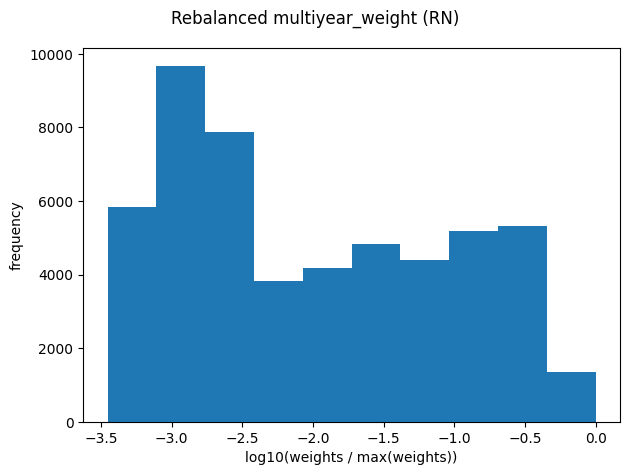

In [10]:

# Rebalance weights for between-years equality
# ============================================
# Modifies param_samples_df in place by adding a column
df = param_samples_df

_year_index = df.index.get_level_values("year")
sum_weights = df.groupby("year")["posterior_weight"].sum().reindex(_year_index)
sum_weights.index = df.index
df["multiyear_weight"] = df["posterior_weight"] / sum_weights  # Rebalance by year
df["multiyear_weight"] /= df["multiyear_weight"].max()  # Normalize to max = 1


# --- Visualize distribution (relative to maximum)
fig, ax = plt.subplots()
ax.hist(np.log10(df["multiyear_weight"] / df["multiyear_weight"].max()))
ax.set_xlabel("log10(weights / max(weights))")
ax.set_ylabel("frequency")
fig.suptitle(f"Rebalanced multiyear_weight ({location_id})")
fig.tight_layout()


In [21]:
# Prepare a full data frame with all relevant variables
# =================================

exclude_vars = [
    "notif_scaling_factor",  # Placeholder, real scaling is `notif_relative_scale`
]

# --- Merge fixed parameters from stage 1
# (Take only parameters that were not explored)
_new_params = [
    p for p in max_likelihood_df.columns
    if p not in param_samples_df.columns
    and p not in exclude_vars
]
df = pd.merge(
    left=param_samples_df.reset_index(),
    right=max_likelihood_df[_new_params],
    on="year",
).set_index(["year", "i_simulation"])

df

# --- Merge with outbreak features
# Todo if needed


multiyear_samples_df = df
multiyear_samples_df

rt_logist_r_high  rt_logist_start  notif_nb_overdispersion  \
year i_simulation                                                               
2010 211349                1.993837        60.748786                18.320134   
     206293                2.007008        63.833842                17.704882   
     246282                1.987904        60.211442                17.849725   
     258552                2.014478        62.430397                20.933380   
     7249                  1.980722        64.460976                 0.439271   
...                             ...              ...                      ...   
2023 19741                 3.425736        93.463602                19.690369   
     226337                3.523115        94.438240                25.747367   
     257376                3.438383        94.693872                23.521820   
     257280                3.498078        94.507589                28.191717   
     258590                3.439279        93.819473                24.296443   

                   posterior_weight  multiyear_weight  rt_logist_dt_center  \
year i_simulation                                                            
2010 211349                0.001122          0.001122            85.099662   
     206293                0.001122          0.001122            85.099662   
     246282                0.001122          0.001122            85.099662   
     258552                0.001122          0.001122            85.099662   
     7249                  0.001122          0.001122            85.099662   
...                             ...               ...                  ...   
2023 19741                 1.000000          0.404362            39.974187   
     226337                1.000000          0.404362            39.974187   
     257376                1.000000          0.404362            39.974187   
     257280                1.000000          0.404362            39.974187   
     258590                1.000000          0.404362            39.974187   

                   rt_logist_dt_end  rt_logist_w_center  rt_logist_w_env  \
year i_simulation                                                          
2010 211349              119.841679           42.732830              2.5   
     206293              119.841679           42.732830              2.5   
     246282              119.841679           42.732830              2.5   
     258552              119.841679           42.732830              2.5   
     7249                119.841679           42.732830              2.5   
...                             ...                 ...              ...   
2023 19741                91.365381           10.801308              2.5   
     226337               91.365381           10.801308              2.5   
     257376               91.365381           10.801308              2.5   
     257280               91.365381           10.801308              2.5   
     258590               91.365381           10.801308              2.5   

                   rt_logist_r_low  rt_logist_r_off  notif_relative_scale  
year i_simulation                                                          
2010 211349                    0.5         0.961808              6.818987  
     206293                    0.5         0.961808              6.818987  
     246282                    0.5         0.961808              6.818987  
     258552                    0.5         0.961808              6.818987  
     7249                      0.5         0.961808              6.818987  
...                            ...              ...                   ...  
2023 19741                     0.5         0.973166              4.401717  
     226337                    0.5         0.973166              4.401717  
     257376                    0.5         0.973166              4.401717  
     257280                    0.5         0.973166              4.401717  
     258590                    0.5         0.9731

## Overall visualizations

In [45]:

from statsmodels.stats.weightstats import DescrStatsW


def _precompute_weighted_boxplot_arrays(
        _df,
        weight_col="weight",
        value_col="values",
):
    """For plotly boxplots"""
    # 2. Compute weighted statistics using statsmodels
    weighted_stats = DescrStatsW(_df[value_col], weights=_df[weight_col])

    # Extract exact weighted percentiles (25th, 50th, 75th)
    q1, median, q3 = weighted_stats.quantile([0.25, 0.50, 0.75]).values

    # Define minimum and maximum boundary values
    val_min = _df[value_col].min()
    val_max = _df[value_col].max()

    # 3. Format the precomputed metrics into Plotly's expected list structure
    # Structure layout: [Min, Q1, Q1, Median, Q3, Q3, Max]
    weighted_box_array = [val_min, q1, q1, median, q3, q3, val_max]

    return weighted_box_array

In [50]:
df = multiyear_samples_df

# Yearly calibration aspects
# ===========================

# For ensemble plots, it's best to sub-sample with weights (e.g. boxplots don't accept weighted calculations)
# ---

df = df.reset_index()

#
# param_name = "rt_logist_r_high"
param_names = [
    "rt_logist_r_high", "rt_logist_start", "notif_nb_overdispersion", # Main parameters
    "rt_logist_dt_center", "rt_logist_dt_end", "rt_logist_w_center",
]

from plotly.subplots import make_subplots

fig = make_subplots(
    rows=len(param_names),
    cols=1,
    # shared_xaxes=True,
    vertical_spacing=0.05,
    # subplot_titles=param_names,
)

for i_param, param_name in enumerate(param_names):
    fig.add_box(
        x=df["year"],
        y=df[param_name],  # PROBLEM: Unweighted
        # y=df.groupby("year").apply(
        #     lambda x: _precompute_weighted_boxplot_arrays(
        #         pd.DataFrame({"values": x, "weight": df.loc[x.index, "multiyear_weight"]}),
        #         weight_col="multiyear_weight",
        #         value_col=param_name,
        #     )
        # ),
        name=param_name,
        row=i_param + 1, col=1,
    )

    # fig.update_xaxes(
    #     title_text="Year" if i_param == len(param_names) - 1 else "",
    #     row=i_param + 1, col=1,
    # )
    fig.update_yaxes(
        title_text=param_name,
        row=i_param + 1, col=1,
    )

    # fig.update_layout(
    #     row=i_param + 1, col=1,
    # )



fig.update_layout(
    title=f"Yearly calibration parameter distributions ({location_id})",
    height=300 * len(param_names), width=800,
    showlegend=False,
    # boxmode="group"
)

# ---
out_fpath = Path(f"../../.local/combine_calibration_years/params_{location_id}.html")
out_fpath.parent.mkdir(exist_ok=True, parents=True)
fig.write_html(out_fpath)
display(fig)